In [ ]:
pip install pandas-gbq

# **Import Library**

In [ ]:
import pandas_gbq
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# **Data Loading**

In [ ]:
project_id = "funnel-and-conversion-analysis"

query = """
SELECT
  fullVisitorId,
  visitId,
  PARSE_DATE('%Y%m%d', date) AS visit_date,
  device.deviceCategory AS device,
  trafficSource.source AS traffic_source,

  MAX(CASE WHEN hits.eCommerceAction.action_type = '2' THEN 1 ELSE 0 END) AS product_view,
  MAX(CASE WHEN hits.eCommerceAction.action_type = '3' THEN 1 ELSE 0 END) AS add_to_cart,
  MAX(CASE WHEN hits.eCommerceAction.action_type = '5' THEN 1 ELSE 0 END) AS checkout,
  MAX(CASE WHEN hits.eCommerceAction.action_type = '6' THEN 1 ELSE 0 END) AS purchase

FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`,
UNNEST(hits) AS hits

GROUP BY
  fullVisitorId,
  visitId,
  visit_date,
  device,
  traffic_source

"""

df = pandas_gbq.read_gbq(query, project_id=project_id)

df.tail()

Downloading: 100%|██████████|


,fullVisitorId,visitId,visit_date,device,traffic_source,product_view,add_to_cart,checkout,purchase
903648,5718512509257951955,1485372189,2017-01-25,mobile,google.com,0,0,0,0
903649,2408682357273434525,1485333315,2017-01-25,desktop,(direct),1,0,0,0
903650,2087880022078046202,1485379213,2017-01-25,desktop,bing,1,1,1,1
903651,5888716568893996188,1485374097,2017-01-25,desktop,(direct),0,0,1,1
903652,98700324422405760,1485333372,2017-01-25,desktop,(direct),1,0,0,0


In [ ]:
df.sort_values("visit_date").head()

,fullVisitorId,visitId,visit_date,device,traffic_source,product_view,add_to_cart,checkout,purchase
880900,5542047417982345824,1470067683,2016-08-01,desktop,(direct),1,1,0,0
67472,7504889983163117126,1470105395,2016-08-01,desktop,youtube.com,0,0,0,0
67473,7951900688405132460,1470071603,2016-08-01,desktop,youtube.com,0,0,0,0
67474,1502413680674337747,1470038422,2016-08-01,desktop,youtube.com,0,0,0,0
67475,0692355001768213534,1470109899,2016-08-01,desktop,youtube.com,0,0,0,0


In [ ]:
df.sort_values("visit_date").tail()

,fullVisitorId,visitId,visit_date,device,traffic_source,product_view,add_to_cart,checkout,purchase
125524,4380297617128133406,1501575432,2017-08-01,desktop,(direct),0,0,0,0
125523,8118710529553353774,1501617904,2017-08-01,desktop,(direct),0,0,0,0
125522,1023983335505742330,1501594780,2017-08-01,desktop,(direct),0,0,0,0
125533,6882470046108892119,1501625954,2017-08-01,desktop,google.com,0,0,0,0
622104,9665502702412598975,1501652749,2017-08-01,mobile,(direct),0,0,0,0


# **Exploratory Data Analysis**

In [ ]:
df.shape

(903653, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 903653 entries, 0 to 903652
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   fullVisitorId   903653 non-null  object        
 1   visitId         903653 non-null  Int64         
 2   visit_date      903653 non-null  datetime64[ns]
 3   device          903653 non-null  object        
 4   traffic_source  903653 non-null  object        
 5   product_view    903653 non-null  Int64         
 6   add_to_cart     903653 non-null  Int64         
 7   checkout        903653 non-null  Int64         
 8   purchase        903653 non-null  Int64         
 9   visit_month     903653 non-null  period[M]     
 10  cohort_month    903653 non-null  period[M]     
 11  cohort_index    903653 non-null  int64         
dtypes: Int64(5), datetime64[ns](1), int64(1), object(3), period[M](2)
memory usage: 87.0+ MB


In [ ]:
# Missing Value Check
df.isnull().sum()

,0
fullVisitorId,0
visitId,0
visit_date,0
device,0
traffic_source,0
product_view,0
add_to_cart,0
checkout,0
purchase,0
visit_month,0


In [ ]:
# Device Distribution
df['device'].value_counts()

,count
device,
desktop,664479
mobile,208725
tablet,30449


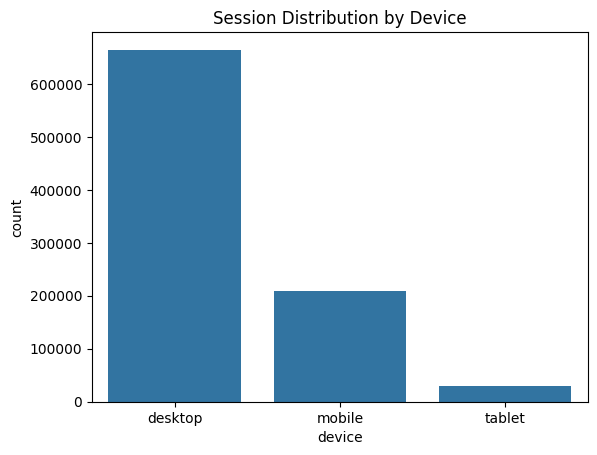

In [ ]:
# Device Distribution
sns.countplot(data=df, x='device')
plt.title("Session Distribution by Device")
plt.show()

In [ ]:
# Traffic Source Distribution
df['traffic_source'].value_counts().head(10)

,count
traffic_source,
(direct),371469
google,241280
youtube.com,212602
Partners,16411
analytics.google.com,16172
dfa,5686
google.com,4669
m.facebook.com,3365
baidu,3356


In [ ]:
# Purchase Rate
df['purchase'].mean()

np.float64(0.012783668067278037)

# **Funnel Conversion Analysis**

In [ ]:
funnel = {
    "Product View": df['product_view'].sum(),
    "Add to Cart": df['add_to_cart'].sum(),
    "Checkout": df['checkout'].sum(),
    "Purchase": df['purchase'].sum()
}
funnel_df = pd.DataFrame(list(funnel.items()), columns=['step','sessions'])
funnel_df

,step,sessions
0,Product View,124188
1,Add to Cart,50139
2,Checkout,22407
3,Purchase,11552


In [ ]:
# Drop-off Rate per Funnel Step
view_to_cart = df['add_to_cart'].sum() / df['product_view'].sum()
cart_to_checkout = df['checkout'].sum() / df['add_to_cart'].sum()
checkout_to_purchase = df['purchase'].sum() / df['checkout'].sum()

print(view_to_cart, cart_to_checkout, checkout_to_purchase)

0.40373466035365735 0.446897624603602 0.5155531753469897


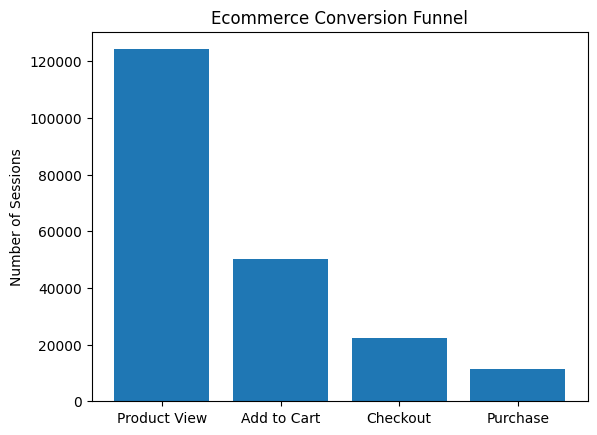

In [ ]:
plt.bar(funnel_df['step'], funnel_df['sessions'])
plt.title("Ecommerce Conversion Funnel")
plt.ylabel("Number of Sessions")
plt.show()

In [ ]:
# Funnel Breakdown by Device
funnel_device = df.groupby('device')[[
    'product_view',
    'add_to_cart',
    'checkout',
    'purchase'
]].sum()

funnel_device['view_to_cart'] = funnel_device['add_to_cart'] / funnel_device['product_view']
funnel_device['cart_to_checkout'] = funnel_device['checkout'] / funnel_device['add_to_cart']
funnel_device['checkout_to_purchase'] = funnel_device['purchase'] / funnel_device['checkout']

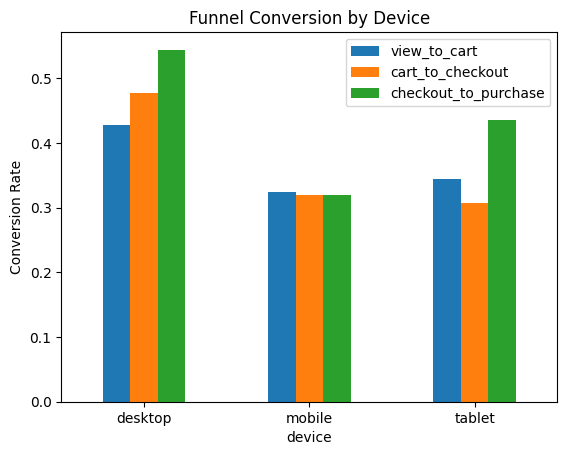

In [ ]:
funnel_device[['view_to_cart','cart_to_checkout','checkout_to_purchase']].plot(kind='bar')

plt.title("Funnel Conversion by Device")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=0)

plt.show()

# **Conversion Rate by Device**



In [ ]:
device_conversion = df.groupby('device')['purchase'].mean().reset_index()
device_conversion

,device,purchase
0,desktop,0.015844
1,mobile,0.004101
2,tablet,0.005517


In [ ]:
# Time to Purchase Analysis
first_visit = df.groupby('fullVisitorId')['visit_date'].min().reset_index()
first_visit.columns = ['fullVisitorId', 'first_visit_date']

purchase_sessions = df[df['purchase'] == 1][['fullVisitorId','visit_date']]
purchase_sessions = purchase_sessions.rename(columns={'visit_date':'purchase_date'})

purchase_time = purchase_sessions.merge(first_visit, on='fullVisitorId')

purchase_time['days_to_purchase'] = (
    purchase_time['purchase_date'] - purchase_time['first_visit_date']
).dt.days

purchase_time['days_to_purchase'].describe()

,days_to_purchase
count,11552.000000
mean,16.322801
std,39.458080
min,0.000000
25%,0.000000
50%,0.000000
75%,13.000000
max,351.000000


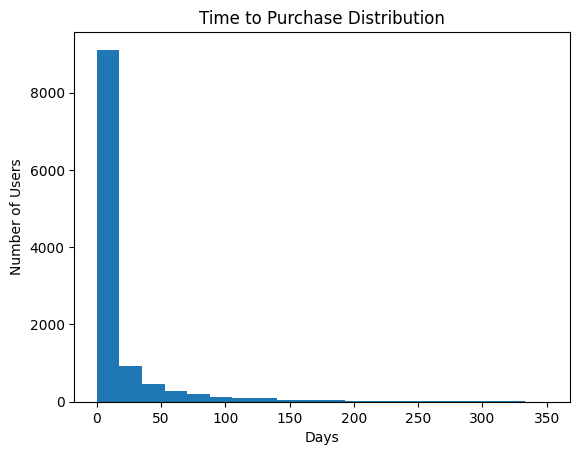

In [ ]:
plt.hist(purchase_time['days_to_purchase'], bins=20)
plt.title("Time to Purchase Distribution")
plt.xlabel("Days")
plt.ylabel("Number of Users")
plt.show()

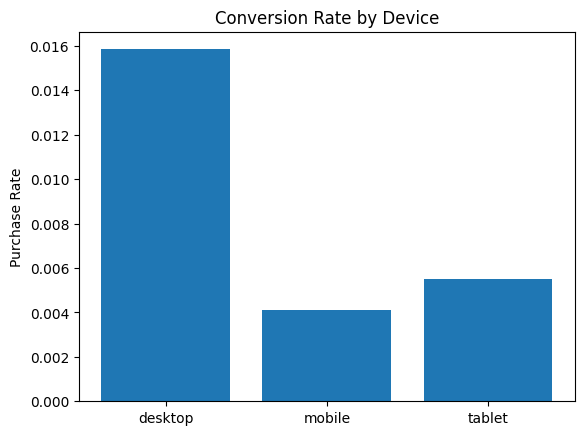

In [ ]:
plt.bar(device_conversion['device'], device_conversion['purchase'])
plt.title("Conversion Rate by Device")
plt.ylabel("Purchase Rate")
plt.show()

# **Conversion by Traffic Source**

In [ ]:
traffic_conversion = (
    df.groupby('traffic_source')['purchase']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

traffic_conversion.head(10)

,traffic_source,purchase
0,basecamp.com,0.5
1,mail.aol.com,0.333333
2,us-mg5.mail.yahoo.com,0.25
3,calendar.google.com,0.2
4,chat.google.com,0.142857
5,search.myway.com,0.125
6,mg.mail.yahoo.com,0.117647
7,trainup.withgoogle.com,0.115385
8,gatewaycdi.com,0.1
9,dealspotr.com,0.075758


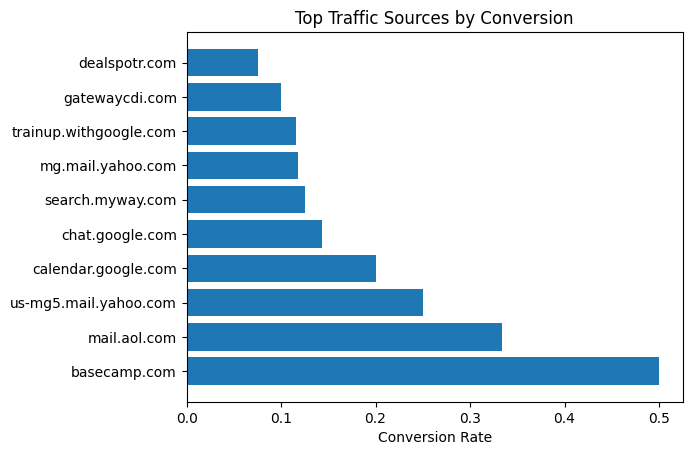

In [ ]:
plt.barh(traffic_conversion['traffic_source'][:10],
         traffic_conversion['purchase'][:10])

plt.title("Top Traffic Sources by Conversion")
plt.xlabel("Conversion Rate")
plt.show()

In [ ]:
# Traffic Share
device_traffic = df['device'].value_counts(normalize=True) * 100
device_traffic_df = device_traffic.reset_index()
device_traffic_df.columns = ['device','traffic_share']

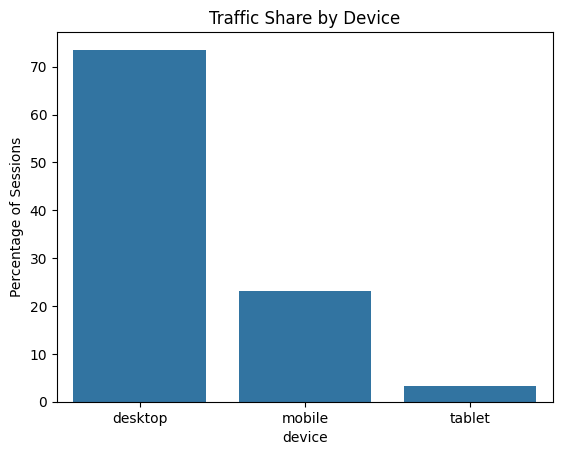

In [ ]:
sns.barplot(data=device_traffic_df, x='device', y='traffic_share')
plt.title("Traffic Share by Device")
plt.ylabel("Percentage of Sessions")
plt.show()

# **Cohort Analysis**

In [ ]:
# Cohort Month
df['visit_date'] = pd.to_datetime(df['visit_date'])
df['visit_month'] = df['visit_date'].dt.to_period('M')

In [ ]:
# First Visit User
df['cohort_month'] = df.groupby('fullVisitorId')['visit_month'].transform('min')

In [ ]:
# Calculate Cohort Index
df['cohort_index'] = (
    (df['visit_month'].dt.year - df['cohort_month'].dt.year) * 12 +
    (df['visit_month'].dt.month - df['cohort_month'].dt.month)
)

In [ ]:
# Cohort Table
cohort_data = df.groupby(['cohort_month','cohort_index'])['fullVisitorId'].nunique().reset_index()

cohort_table = cohort_data.pivot(index='cohort_month',
                                 columns='cohort_index',
                                 values='fullVisitorId')

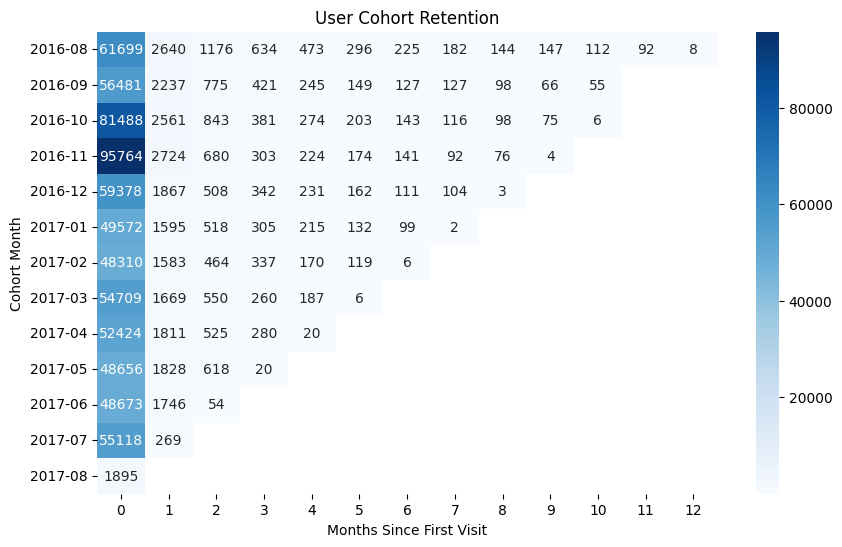

In [ ]:
# Cohort Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(cohort_table, annot=True, fmt=".0f", cmap="Blues")

plt.title("User Cohort Retention")
plt.ylabel("Cohort Month")
plt.xlabel("Months Since First Visit")

plt.show()